In [1]:
import pandas as pd

df = pd.read_csv("../../data/12k_all_results.csv")

In [2]:
df.columns.to_list()

['global_id',
 'sequence',
 'leah_12k_N6_1',
 'leah_12k_R6_1',
 'leah_12k_N6_2',
 'leah_12k_R6_2',
 'leah_12k_N6_3',
 'leah_12k_R6_3',
 'dna_sequence',
 'twist_dna_read_percentile',
 'leah_12k_logFC',
 'leah_12k_logCPM',
 'leah_12k_LR',
 'leah_12k_PValue',
 'leah_12k_FDR',
 'leah_12k_2fold_threshold',
 'leah_12k_Significant',
 'leah_12k_final_score',
 'leah_12k_detected',
 'leah_top10_cytotox_AUC_R_CD20',
 'leah_top10_cytotox_AUC_K_Control',
 'leah_top10_fold_change_CTV_MFI_AUC_proliferation',
 'leah_top10_cytotox_AUC_R_minus_K',
 'leah_top10_percent_cytokine_positive',
 'leah_top10_fold_change_total_cell_count_per_well_expansion',
 'leah_top10_cytotox_AUC_R_minus_K_minmax_norm',
 'leah_top10_percent_cytokine_positive_minmax_norm',
 'leah_top10_fold_change_total_cell_count_per_well_expansion_minmax_norm',
 'leah_top10_sum_of_norms',
 'leah_12k_isup',
 'leah_12k_twist_dna_detected',
 'leah_12k_2fold_threshold_int',
 'fourclass',
 'team']

In [3]:
with open("../../data/_adaptyv_selection_data/seqs_up.fasta", "w") as f:
    up_df = df[df["fourclass"] == "Up"]
    up_seqs = up_df["sequence"].tolist()
    up_ids = up_df["global_id"].tolist()
    for seq_id, seq in zip(up_ids, up_seqs):
        f.write(f">{seq_id}\n{seq}\n")

with open("../../data/_adaptyv_selection_data/seqs_down.fasta", "w") as f:
    down_df = df[df["fourclass"] == "Down"]
    down_seqs = down_df["sequence"].tolist()
    down_ids = down_df["global_id"].tolist()
    for seq_id, seq in zip(down_ids, down_seqs):
        f.write(f">{seq_id}\n{seq}\n")

with open("../../data/_adaptyv_selection_data/seqs_notsig.fasta", "w") as f:
    notsig_df = df[df["fourclass"] == "Not Sig"]
    notsig_seqs = notsig_df["sequence"].tolist()
    notsig_ids = notsig_df["global_id"].tolist()
    for seq_id, seq in zip(notsig_ids, notsig_seqs):
        f.write(f">{seq_id}\n{seq}\n")

with open("../../data/_adaptyv_selection_data/seqs_other.fasta", "w") as f:
    other_df = df[~df["fourclass"].isin(["Up", "Down", "Not Sig"])]
    other_seqs = other_df["sequence"].tolist()
    other_ids = other_df["global_id"].tolist()
    for seq_id, seq in zip(other_ids, other_seqs):
        f.write(f">{seq_id}\n{seq}\n")

now go run mmseqs on each of these

In [4]:
top_ten_df = pd.read_csv("../../data/individual/master_data_top10.csv")[["global_id"]].iloc[2:].reset_index(drop=True) # remove controls
top_ten_df["global_id"] = top_ten_df["global_id"].astype(int)
final_df = top_ten_df.copy()

In [5]:
up_clusters_df = pd.read_csv("../../data/_adaptyv_selection_data/seqs_up_results_cluster.tsv", sep="\t", header=None)
up_clusters_df.columns = ["global_id", "cluster_member"]

# remove rows containing ids from final_df["global_id"]
print("Before removing final_df ids:", len(up_clusters_df))
# print("Removing rows:")
# removed_rows = up_clusters_df[up_clusters_df["cluster_member"].isin(final_df["global_id"])]
# print(removed_rows)
up_clusters_df = up_clusters_df[~up_clusters_df["global_id"].isin(final_df["global_id"])]
# print rows that were removed
print("After removing final_df ids:", len(up_clusters_df))
# randomly select 20 unique cluster members
up_clusters_df = up_clusters_df.drop_duplicates(subset=["global_id"])
up_clusters_df = up_clusters_df.sample(n=20, random_state=89348928)
final_df = pd.concat([final_df, up_clusters_df[["global_id"]]], ignore_index=True)

Before removing final_df ids: 707
After removing final_df ids: 672


In [6]:
down_clusters_df = pd.read_csv("../../data/_adaptyv_selection_data/seqs_down_results_cluster.tsv", sep="\t", header=None)
down_clusters_df.columns = ["cluster_rep", "global_id"]

# add in "final score"
down_clusters_df = down_clusters_df.merge(
    df[["global_id", "leah_12k_final_score"]], on="global_id", how="left"
).sort_values(by="leah_12k_final_score", ascending=True)

# drop duplicates in order of final score
down_clusters_df = down_clusters_df.drop_duplicates(subset=["cluster_rep"])
down_clusters_df = down_clusters_df.iloc[:10].reset_index(drop=True)

final_df = pd.concat([final_df, down_clusters_df[["global_id"]]], ignore_index=True)

In [7]:
down_clusters_df

,cluster_rep,global_id,leah_12k_final_score
0,6399,6399,-107.673438
1,3555,3555,-82.049057
2,4584,4584,-38.659601
3,11186,11186,-33.589906
4,7722,7722,-32.379679
5,2577,2577,-28.414598
6,3732,3732,-25.379714
7,11257,11257,-23.511109
8,10621,10621,-18.622482
9,472,796,-11.441519


In [8]:
# randomly sample 60 sequences from seqs_notsig_results_rep_seq.fasta
# load fasta
from Bio import SeqIO
notsig_seqs = list(SeqIO.parse("../../data/_adaptyv_selection_data/seqs_notsig_results_rep_seq.fasta", "fasta"))
notsig_ids = [int(record.id) for record in notsig_seqs]
notsig_df = pd.DataFrame({"global_id": notsig_ids})
notsig_df = notsig_df[~notsig_df["global_id"].isin(final_df["global_id"])]
notsig_df = notsig_df.sample(n=60, random_state=39389851).reset_index(drop=True)
notsig_df
final_df = pd.concat([final_df, notsig_df[["global_id"]]], ignore_index=True)

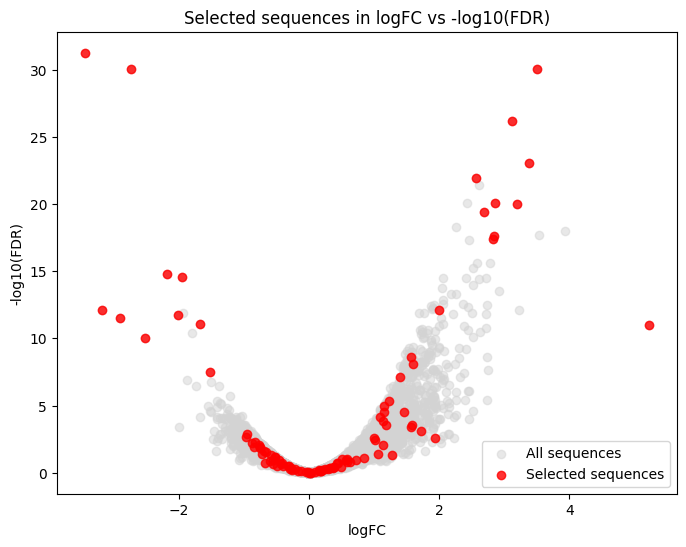

In [9]:
# merge w/ -logfdr and logfc
final_df = final_df.merge(
    df[["global_id", "sequence", "leah_12k_logFC", "leah_12k_FDR"]], on="global_id", how="left"
)

df = df.dropna(subset=["leah_12k_FDR", "leah_12k_logFC"])

# plot logFC vs -logFDR of the entire df, making sure to highlight those in final_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(df["leah_12k_logFC"], -np.log10(df["leah_12k_FDR"]), color="lightgray", alpha=0.5, label="All sequences")
plt.scatter(final_df["leah_12k_logFC"], -np.log10(final_df["leah_12k_FDR"]), color="red", alpha=0.8, label="Selected sequences")
plt.xlabel("logFC")
plt.ylabel("-log10(FDR)")
plt.title("Selected sequences in logFC vs -log10(FDR)")
plt.legend()
plt.show()


In [10]:
def get_class(val):
    if val >=1:
        return "Up"
    elif val <= -1:
        return "Down"
    elif val > -1 and val < 1:
        return "Not Sig"

final_df["class"] = final_df["leah_12k_logFC"].apply(get_class)

In [11]:
# import seaborn as sns
# import numpy as np
# import matplotlib.pyplot as plt

# results_df = pd.read_csv("b2b_summary.csv")
# results_df = results_df[["name", "kd", "binding_strength", "expression"]].rename(columns={"name": "global_id"})

# # Convert global_id to string for consistent merging
# results_df["global_id"] = results_df["global_id"].astype(str)
# final_df["global_id"] = final_df["global_id"].astype(str)

# # Merge with final_df to get class assignments
# results_df = results_df.merge(final_df[["global_id", "class"]], on="global_id", how="left")

# expression_counts = results_df.groupby("global_id")["expression"].apply(lambda x: (x == "none").sum()).reset_index(name="none_count")
# print(expression_counts[["none_count"]].value_counts())

# # Assign controls manually
# results_df.loc[results_df["global_id"] == "scFv", "class"] = "Control"

# # Define order
# up_ids = final_df[final_df["class"] == "Up"]["global_id"].tolist()
# down_ids = final_df[final_df["class"] == "Down"]["global_id"].tolist()
# notsig_ids = final_df[final_df["class"] == "Not Sig"]["global_id"].tolist()
# top_ten = ["1304", "1506", "1892", "2383", "3109", "3494", "3718", "5300", "5624", "5981"]
# up_ids_notopten = [id for id in up_ids if id not in top_ten]

# order = ["scFv"] + top_ten + sorted(up_ids_notopten, key=int) + sorted(down_ids, key=int) + sorted(notsig_ids, key=int)

# # Calculate group boundaries for vertical lines
# group_boundaries = []
# group_boundaries.append(len(["scFv"]) - 0.5)  # After control
# group_boundaries.append(len(["scFv"] + top_ten) - 0.5)  # After top ten
# group_boundaries.append(len(["scFv"] + top_ten + sorted(up_ids_notopten, key=int)) - 0.5)  # After remaining Up
# group_boundaries.append(len(["scFv"] + top_ten + sorted(up_ids_notopten, key=int) + sorted(down_ids, key=int)) - 0.5)  # After Down

# # Filter to only include IDs in our order list
# results_df = results_df[results_df["global_id"].isin(order)]

# # Set categorical order
# results_df["global_id"] = pd.Categorical(results_df["global_id"], categories=order, ordered=True)
# results_df = results_df.sort_values("global_id").reset_index(drop=True)

# # Invert Kd so lower Kd = taller bar (higher affinity)
# results_df["affinity"] = 1 / results_df["kd"]
# results_df["affinity"] = results_df["affinity"].fillna(0)

# # Define color palette
# palette = {"Control": "gray", "Up": "firebrick", "Down": "steelblue", "Not Sig": "lightgray"}

# # Define weak binders and non-expressed
# weak_binders = ["3339", "1479", "1506", "2941", "5981"]
# non_expressed = expression_counts[expression_counts["none_count"] > 0]["global_id"].tolist()

# # Plot
# fig, ax = plt.subplots(figsize=(20, 4))
# sns.barplot(data=results_df, x="global_id", y="affinity", hue="class", palette=palette, dodge=False, ax=ax)

# ax.set_yscale('log')

# # FIXED: Set x-axis limits to remove large margins
# num_bars = len(results_df["global_id"].cat.categories)
# ax.set_xlim(-0.5, num_bars - 0.5)

# # Add vertical lines between groups
# for boundary in group_boundaries:
#     ax.axvline(x=boundary, color='black', linestyle='--', linewidth=1, alpha=0.5)

# # Get y position just below the x-axis (in data coordinates after log scale)
# y_lim = ax.get_ylim()
# y_marker = y_lim[0] * 0.8  # Place markers slightly below the bottom of the plot

# # Add circles for weak binders
# for weak_id in weak_binders:
#     if weak_id in results_df["global_id"].values:
#         x_pos = list(results_df["global_id"].cat.categories).index(weak_id)
#         sample_class = results_df[results_df["global_id"] == weak_id]["class"].values[0]
#         color = palette.get(sample_class, "black")
#         ax.scatter(x_pos, y_marker, s=100, color=color, edgecolor="black", 
#                    linewidth=1.5, zorder=5, clip_on=False)

# # Add X markers for non-expressed
# for non_expr_id in non_expressed:
#     if non_expr_id in results_df["global_id"].values:
#         x_pos = list(results_df["global_id"].cat.categories).index(non_expr_id)
#         sample_class = results_df[results_df["global_id"] == non_expr_id]["class"].values[0]
#         color = palette.get(sample_class, "black")
#         ax.scatter(x_pos, y_marker, s=150, marker='x', color='red', 
#                    linewidth=2.5, zorder=6, clip_on=False)

# # Add legend entries
# ax.scatter([], [], s=100, color="white", edgecolor="black", linewidth=1.5, label="Weak Binders")
# ax.scatter([], [], s=150, marker='x', color='red', linewidth=2.5, label="Non-expressed")

# # Set y-axis tick labels to show negative exponents
# yticks = ax.get_yticks()
# yticklabels = [f'$10^{{{int(np.log10(tick)) * -1}}}$' if tick > 0 else '' for tick in yticks]
# ax.set_yticklabels(yticklabels)

# ax.set_xlabel("Sample ID")
# ax.set_ylabel("Kd (M)")
# plt.xticks(rotation=90, ha="center", fontsize=8)

# # Get handles and labels for legend
# handles, labels = ax.get_legend_handles_labels()

# # rename legend labels: Up -> ≥2-fold increase
# labels = [label.replace("Up", "≥2-fold Increase") for label in labels]
# labels = [label.replace("Down", "≥2-fold Decrease") for label in labels]
# plt.legend(handles=handles, labels=labels, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

# plt.tight_layout()
# plt.savefig("binding_affinity_barplot.png", dpi=300)

none_count
0             84
3             17
Name: count, dtype: int64


/tmp/ipykernel_1379641/840886387.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


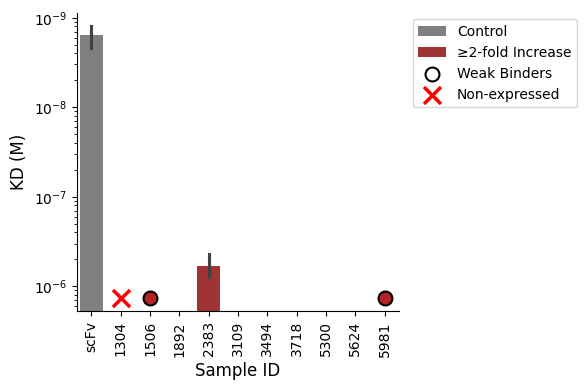

In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.read_csv("b2b_summary.csv")
results_df = results_df[["name", "kd", "binding_strength", "expression"]].rename(columns={"name": "global_id"})

# Convert global_id to string for consistent merging
results_df["global_id"] = results_df["global_id"].astype(str)
final_df["global_id"] = final_df["global_id"].astype(str)

# Merge with final_df to get class assignments
results_df = results_df.merge(final_df[["global_id", "class"]], on="global_id", how="left")

expression_counts = results_df.groupby("global_id")["expression"].apply(lambda x: (x == "none").sum()).reset_index(name="none_count")
print(expression_counts[["none_count"]].value_counts())

# Assign controls manually
results_df.loc[results_df["global_id"] == "scFv", "class"] = "Control"

# Define order
up_ids = final_df[final_df["class"] == "Up"]["global_id"].tolist()
down_ids = final_df[final_df["class"] == "Down"]["global_id"].tolist()
notsig_ids = final_df[final_df["class"] == "Not Sig"]["global_id"].tolist()
top_ten = ["1304", "1506", "1892", "2383", "3109", "3494", "3718", "5300", "5624", "5981"]
up_ids_notopten = [id for id in up_ids if id not in top_ten]

order = ["scFv"] + top_ten

# Calculate group boundaries for vertical lines
group_boundaries = []
group_boundaries.append(len(["scFv"]) - 0.5)  # After control
group_boundaries.append(len(["scFv"] + top_ten) - 0.5)  # After top ten
group_boundaries.append(len(["scFv"] + top_ten + sorted(up_ids_notopten, key=int)) - 0.5)  # After remaining Up
group_boundaries.append(len(["scFv"] + top_ten + sorted(up_ids_notopten, key=int) + sorted(down_ids, key=int)) - 0.5)  # After Down

# Filter to only include IDs in our order list
results_df = results_df[results_df["global_id"].isin(order)]

# Set categorical order
results_df["global_id"] = pd.Categorical(results_df["global_id"], categories=order, ordered=True)
results_df = results_df.sort_values("global_id").reset_index(drop=True)

# Invert Kd so lower Kd = taller bar (higher affinity)
results_df["affinity"] = 1 / results_df["kd"]
results_df["affinity"] = results_df["affinity"].fillna(0)

# Define color palette
palette = {"Control": "gray", "Up": "firebrick", "Down": "steelblue", "Not Sig": "lightgray"}

# Define weak binders and non-expressed
weak_binders = ["3339", "1479", "1506", "2941", "5981"]
non_expressed = expression_counts[expression_counts["none_count"] > 0]["global_id"].tolist()

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=results_df, x="global_id", y="affinity", hue="class", palette=palette, dodge=False, ax=ax)

ax.set_yscale('log')

# FIXED: Set x-axis limits to remove large margins
num_bars = len(results_df["global_id"].cat.categories)
ax.set_xlim(-0.5, num_bars - 0.5)

# # Add vertical lines between groups
# for boundary in group_boundaries:
#     ax.axvline(x=boundary, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Get y position just below the x-axis (in data coordinates after log scale)
y_lim = ax.get_ylim()
y_marker = y_lim[0] * 0.8  # Place markers slightly below the bottom of the plot

# Add circles for weak binders
for weak_id in weak_binders:
    if weak_id in results_df["global_id"].values:
        x_pos = list(results_df["global_id"].cat.categories).index(weak_id)
        sample_class = results_df[results_df["global_id"] == weak_id]["class"].values[0]
        color = palette.get(sample_class, "black")
        ax.scatter(x_pos, y_marker, s=100, color=color, edgecolor="black", 
                   linewidth=1.5, zorder=5, clip_on=False)

# Add X markers for non-expressed
for non_expr_id in non_expressed:
    if non_expr_id in results_df["global_id"].values:
        x_pos = list(results_df["global_id"].cat.categories).index(non_expr_id)
        sample_class = results_df[results_df["global_id"] == non_expr_id]["class"].values[0]
        color = palette.get(sample_class, "black")
        ax.scatter(x_pos, y_marker, s=150, marker='x', color='red', 
                   linewidth=2.5, zorder=6, clip_on=False)

# Add legend entries
ax.scatter([], [], s=100, color="white", edgecolor="black", linewidth=1.5, label="Weak Binders")
ax.scatter([], [], s=150, marker='x', color='red', linewidth=2.5, label="Non-expressed")

# Set y-axis tick labels to show negative exponents
yticks = ax.get_yticks()
yticklabels = [f'$10^{{{int(np.log10(tick)) * -1}}}$' if tick > 0 else '' for tick in yticks]
ax.set_yticklabels(yticklabels)

ax.set_xlabel("Sample ID", fontsize=12)
ax.set_ylabel("KD (M)", fontsize=12)
plt.xticks(rotation=90, ha="center", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Get handles and labels for legend
handles, labels = ax.get_legend_handles_labels()

# rename legend labels: Up -> ≥2-fold increase
labels = [label.replace("Up", "≥2-fold Increase") for label in labels]
labels = [label.replace("Down", "≥2-fold Decrease") for label in labels]
plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)

# remove top and righ tpsines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("binding_affinity_barplot_top10.png", dpi=300)